In [1]:
import numpy as np
import pandas as pd
import joblib
from itertools import combinations


# ── 1. Load saved FactorAnalyzer objects ─────────────────────────────────────

fa1 = joblib.load("./../../data/03_final/PPMI_FA_model_P3OFF.joblib")['fa']
fa2 = joblib.load("../../data/03_final/OPDC_FA_model_P3ON.joblib")['fa']
fa3 = joblib.load("./../../data/03_final/TRACKING_FA_model_P3OFF.joblib")['fa']

dataset_names = ["PPMI", "OPDC", "Tracking"]  # update as needed
fa_models     = [fa1, fa2, fa3]

# Extract loadings from each saved model
loadings_dict = {
    name: fa.loadings_
    for name, fa in zip(dataset_names, fa_models)
}


# ── 2. Tucker's Congruence Coefficient ───────────────────────────────────────

def tucker_congruence(loadings1: np.ndarray, loadings2: np.ndarray) -> np.ndarray:
    """
    Returns an (n_factors x n_factors) matrix where cell [i, j]
    is the congruence between factor i of solution 1 and factor j of solution 2.
    """
    n_f1 = loadings1.shape[1]
    n_f2 = loadings2.shape[1]
    congruence_matrix = np.zeros((n_f1, n_f2))

    for i in range(n_f1):
        for j in range(n_f2):
            f1 = loadings1[:, i]
            f2 = loadings2[:, j]
            numerator   = np.sum(f1 * f2)
            denominator = np.sqrt(np.sum(f1 ** 2) * np.sum(f2 ** 2))
            congruence_matrix[i, j] = (
                numerator / denominator if denominator != 0 else np.nan
            )

    return congruence_matrix


# ── 3. Pairwise comparisons ───────────────────────────────────────────────────

n_factors     = fa1.loadings_.shape[1]
factor_labels = [f"F{i + 1}" for i in range(n_factors)]

print("Tucker's Congruence Coefficients")
print("Guideline:  ≥ 0.95 excellent  |  0.85–0.94 fair  |  < 0.85 poor")
print("=" * 60)

congruence_results = {}

for name_a, name_b in combinations(dataset_names, 2):
    congruence = tucker_congruence(loadings_dict[name_a], loadings_dict[name_b])
    key = f"{name_a} vs {name_b}"
    congruence_results[key] = congruence

    df_cong = pd.DataFrame(
        congruence,
        index   = [f"{f} ({name_a})" for f in factor_labels],
        columns = [f"{f} ({name_b})" for f in factor_labels],
    )
    print(f"\n{key}:")
    print(df_cong.round(3).to_string())


Tucker's Congruence Coefficients
Guideline:  ≥ 0.95 excellent  |  0.85–0.94 fair  |  < 0.85 poor

PPMI vs OPDC:
           F1 (OPDC)  F2 (OPDC)  F3 (OPDC)  F4 (OPDC)  F5 (OPDC)  F6 (OPDC)
F1 (PPMI)      0.555      0.983      0.203      0.208      0.403      0.527
F2 (PPMI)      0.530      0.215      0.204      0.983      0.375      0.560
F3 (PPMI)      0.984      0.477      0.161      0.457      0.445      0.488
F4 (PPMI)      0.527      0.498      0.139      0.473      0.932      0.169
F5 (PPMI)      0.094      0.101      0.925      0.121      0.126      0.172
F6 (PPMI)      0.239      0.255      0.757      0.261      0.133     -0.135

PPMI vs Tracking:
           F1 (Tracking)  F2 (Tracking)  F3 (Tracking)  F4 (Tracking)  F5 (Tracking)  F6 (Tracking)
F1 (PPMI)          0.563          0.866          0.307          0.283          0.465          0.540
F2 (PPMI)          0.553          0.392          0.095          0.875          0.470          0.549
F3 (PPMI)          0.975          0.4

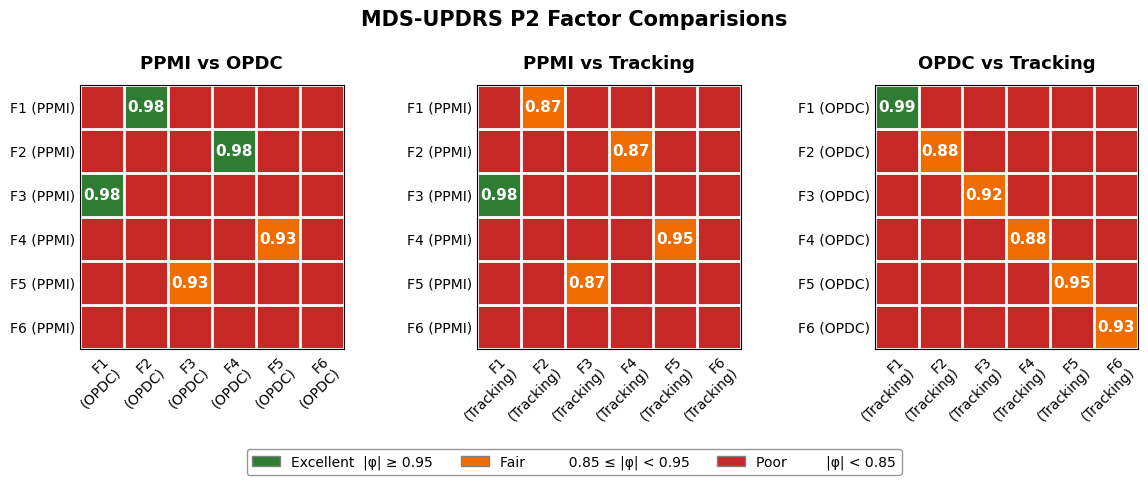

Figure saved → ../Results/P2_factor_comp.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm


def plot_congruence_heatmaps(
    congruence_results: dict,
    n_factors: int,
    figsize_per_panel: tuple = (4, 4),
    save_path: str = "tucker_congruence.png",
    fair_cutoff: float = 0.85,
    excellent_cutoff: float = 0.95,
    title = ''
):
    """
    Plot Tucker's Congruence Coefficient heatmaps for all pairwise comparisons.

    Colour coding (based on |φ|):
        Green  → Excellent  |φ| ≥ excellent_cutoff
        Orange → Fair       fair_cutoff ≤ |φ| < excellent_cutoff
        Red    → Poor       |φ| < fair_cutoff

    Cell annotations:
        - ONLY show numbers for green/orange cells
        - Rounded to 2 decimal places
        - Uses signed φ in the label, but thresholds use |φ|
    """
    n_pairs = len(congruence_results)

    fig, axes = plt.subplots(
        1, n_pairs,
        figsize=(figsize_per_panel[0] * n_pairs, figsize_per_panel[1]),
    )
    if n_pairs == 1:
        axes = [axes]

    # Discrete colourmap: red, orange, green
    cmap = ListedColormap(["#c62828", "#ef6c00", "#2e7d32"])
    bounds = [-0.001, fair_cutoff, excellent_cutoff, 1.001]  # poor, fair, excellent
    norm = BoundaryNorm(bounds, cmap.N)

    for ax, (key, congruence) in zip(axes, congruence_results.items()):
        abs_cong = np.abs(congruence)
        ax.imshow(abs_cong, cmap=cmap, norm=norm, aspect="equal")

        # Annotate ONLY fair/excellent cells, rounded to 2dp
        for i in range(n_factors):
            for j in range(n_factors):
                mag = abs_cong[i, j]
                if mag >= fair_cutoff:  # fair or excellent
                    val = congruence[i, j]  # show signed value
                    ax.text(
                        j, i, f"{val:.2f}",
                        ha="center", va="center",
                        fontsize=11, fontweight="bold", color="white",
                    )

        # Axis labels
        name_a, name_b = key.split(" vs ")
        ax.set_xticks(range(n_factors))
        ax.set_yticks(range(n_factors))
        ax.set_xticklabels(
            [f"F{k + 1}\n({name_b})" for k in range(n_factors)],
            fontsize=10,
            rotation=45,
            ha="right",
            rotation_mode="anchor",
        )
        ax.set_yticklabels([f"F{k + 1} ({name_a})" for k in range(n_factors)], fontsize=10)
        ax.set_title(key, fontsize=13, fontweight="bold", pad=12)
        ax.tick_params(length=0)

        # White grid lines
        for pos in np.arange(-0.5, n_factors, 1):
            ax.axhline(pos, color="white", linewidth=2)
            ax.axvline(pos, color="white", linewidth=2)

    # Legend
    legend_patches = [
        mpatches.Patch(facecolor="#2e7d32", edgecolor="grey",
                       label=f"Excellent  |φ| ≥ {excellent_cutoff:.2f}"),
        mpatches.Patch(facecolor="#ef6c00", edgecolor="grey",
                       label=f"Fair          {fair_cutoff:.2f} ≤ |φ| < {excellent_cutoff:.2f}"),
        mpatches.Patch(facecolor="#c62828", edgecolor="grey",
                       label=f"Poor         |φ| < {fair_cutoff:.2f}"),
    ]
    fig.legend(
        handles=legend_patches,
        loc="lower center",
        ncol=3,
        fontsize=10,
        bbox_to_anchor=(0.5, -0.15),
        frameon=True,
        edgecolor="grey",
    )

    fig.suptitle(f"{title}", fontsize=15, fontweight="bold", y=1.03)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Figure saved → {save_path}")


# Call
plot_congruence_heatmaps(
    congruence_results=congruence_results,
    n_factors=fa1.loadings_.shape[1],
    save_path='../Results/P2_factor_comp.png',
    title = 'MDS-UPDRS P2 Factor Comparisions'
)
